# LSTM Forecasting

## 1. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

tf.random.set_seed(42)
np.random.seed(42)

## 2. Load Dataset

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"

df_raw = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(df_raw)
target = df_daily["Close"].dropna().asfreq("D")

df_daily.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00+00:00,4.58,5.00,4.58,5.00,21.602000
2012-01-02 00:00:00+00:00,5.00,5.00,5.00,5.00,19.048000
2012-01-03 00:00:00+00:00,5.00,5.32,5.00,5.29,88.037281
2012-01-04 00:00:00+00:00,5.29,5.57,4.93,5.57,107.233260
2012-01-05 00:00:00+00:00,5.57,6.65,5.57,6.65,94.801829


## 3. Train-Test Split

In [3]:
split_idx = int(len(target) * 0.8)

train = target.iloc[:split_idx]
test = target.iloc[split_idx:]

train.shape, test.shape

((4241,), (1061,))

## 4. Data Scaling

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_values = train.to_numpy().reshape(-1, 1)
test_values = test.to_numpy().reshape(-1, 1)

train_scaled = scaler.fit_transform(train_values)
test_scaled = scaler.transform(test_values)

## 5. Sequence Creation

In [5]:
LOOKBACK = 30


def create_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback : i])
        y.append(values[i])
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, LOOKBACK)

combined_scaled = np.vstack([train_scaled[-LOOKBACK:], test_scaled])
X_test, y_test_scaled = create_sequences(combined_scaled, LOOKBACK)
y_test = test.copy()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4211, 30, 1), (4211, 1), (1061, 30, 1), (1061,))

## 6. Build LSTM Model

In [6]:
model = Sequential(
    [
        LSTM(32, input_shape=(LOOKBACK, 1)),
        Dense(1),
    ]
)

model.compile(optimizer="adam", loss="mse")
model.summary()

E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train Model

Epoch 1/50


  1/119 ━━━━━━━━━━━━━━━━━━━━ 8:06 4s/step - loss: 1.7285e-10

  6/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2762e-05

 10/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0540e-05

 14/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.9743e-06

...

107/119 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.5582e-04

111/119 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.7429e-04

115/119 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.5819e-04

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011    

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0011 - val_loss: 0.0020


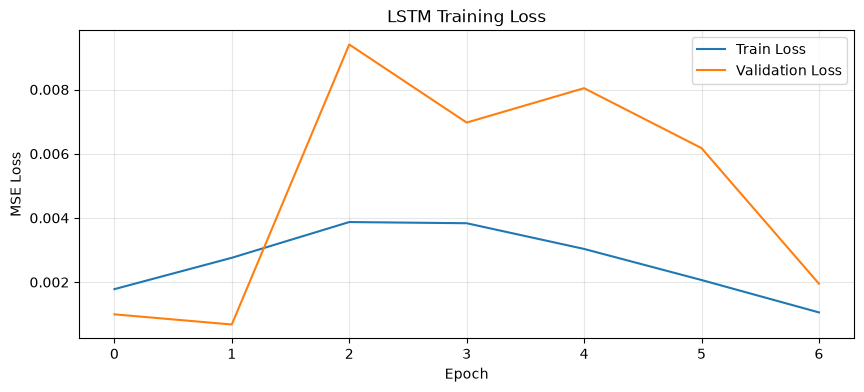

In [7]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    shuffle=False,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Validation Loss")
ax.set_title("LSTM Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 8. Generate Forecasts

 1/34 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step

11/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step   

20/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

30/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


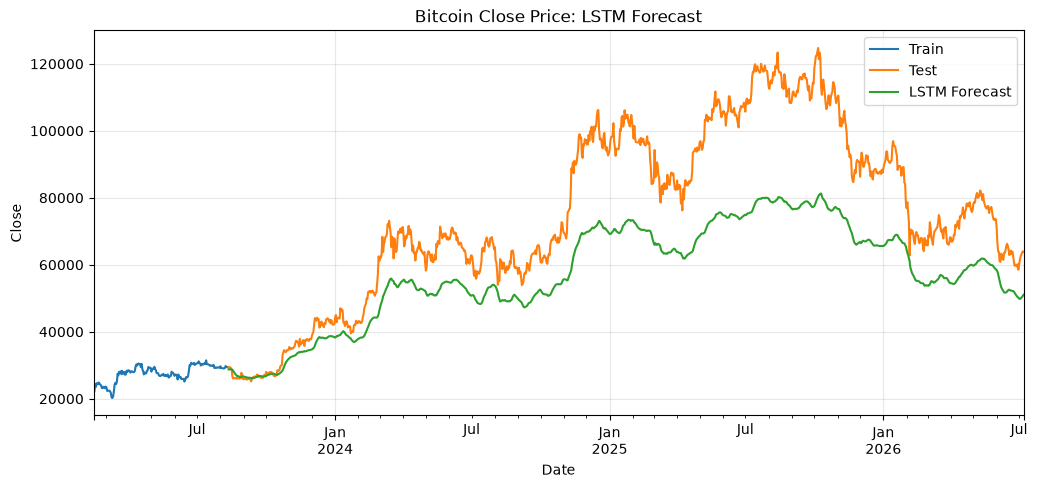

In [8]:
lstm_predictions_scaled = model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled).ravel()
lstm_forecast = pd.Series(lstm_predictions, index=test.index, name="LSTM")

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
lstm_forecast.plot(ax=ax, label="LSTM Forecast")
ax.set_title("Bitcoin Close Price: LSTM Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 9. Evaluation Metrics

In [9]:
def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }


lstm_metrics = pd.DataFrame(
    [evaluate_forecast(y_test, lstm_forecast)],
    index=["LSTM"],
)

lstm_metrics

,MAE,RMSE,MAPE,sMAPE
LSTM,17737.421455,20865.805411,20.881144,23.790361


## 10. Compare with Classical Benchmark

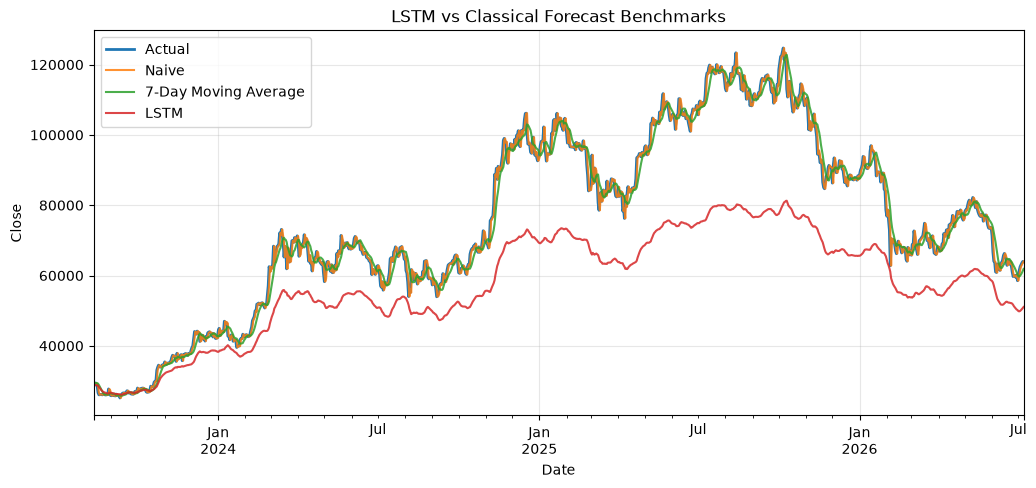

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
LSTM,17737.421455,20865.805411,20.881144,23.790361


In [10]:
naive_forecast = target.shift(1).reindex(test.index).rename("Naive")
moving_average_forecast = (
    target.shift(1)
    .rolling(window=7)
    .mean()
    .reindex(test.index)
    .rename("7-Day Moving Average")
)

benchmark_forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "LSTM": lstm_forecast,
}

comparison_table = pd.DataFrame(
    [evaluate_forecast(y_test, forecast) for forecast in benchmark_forecasts.values()],
    index=benchmark_forecasts.keys(),
)

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in benchmark_forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("LSTM vs Classical Forecast Benchmarks")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

comparison_table.sort_values("RMSE")

## 11. Key Findings
- This notebook starts with a simple single-layer LSTM using a 30-day lookback window.
- The LSTM forecast is evaluated on the same chronological test period as the classical baselines.
- Naive and 7-day moving average forecasts provide lightweight benchmarks for judging whether the LSTM adds value.
- Lower MAE, RMSE, MAPE, and sMAPE values indicate stronger out-of-sample performance.

## 12. LSTM Diagnostics

In [ ]:
diagnostics = pd.DataFrame(
    {
        "Actual": y_test,
        "LSTM": lstm_forecast,
        "Naive": naive_forecast,
    }
)

print("First 10 actual values:")
print(y_test.head(10).to_string())

print("\nFirst 10 LSTM predictions:")
print(lstm_forecast.head(10).to_string())

print("\nFirst 10 Naive predictions:")
print(naive_forecast.head(10).to_string())

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)
print("X_train sequence shape:", X_train.shape)
print("y_train sequence shape:", y_train.shape)
print("X_test sequence shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Scaling range:", scaler.feature_range)
print("Train scaled min/max:", float(train_scaled.min()), float(train_scaled.max()))
print("Test scaled min/max:", float(test_scaled.min()), float(test_scaled.max()))

lstm_error = y_test - lstm_forecast
naive_error = y_test - naive_forecast
lag_correlation = y_test.corr(lstm_forecast.shift(1))
same_day_correlation = y_test.corr(lstm_forecast)
lstm_volatility_ratio = lstm_forecast.diff().std() / y_test.diff().std()

print("\nPrediction lag check:")
print("Actual vs same-day LSTM correlation:", same_day_correlation)
print("Actual vs previous-day LSTM correlation:", lag_correlation)

print("\nUnderfitting check:")
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])
print("LSTM MAE / Naive MAE:", mae(y_test, lstm_forecast) / mae(y_test, naive_forecast))

print("\nOver-smoothing check:")
print("LSTM prediction std:", lstm_forecast.std())
print("Actual test std:", y_test.std())
print("LSTM daily-change std / Actual daily-change std:", lstm_volatility_ratio)

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.plot(ax=ax, label="Naive", alpha=0.85)
lstm_forecast.plot(ax=ax, label="LSTM", alpha=0.85)
ax.set_title("LSTM Diagnostics: Actual vs Naive vs LSTM")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Validation Loss")
ax.set_title("LSTM Training Loss History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Bitcoin closing prices are highly persistent, noisy, and regime-dependent, so a one-step naive baseline can be very hard to beat. A simple single-layer LSTM trained only on univariate close prices may underperform because it can smooth sharp moves, lag turning points, and fail to learn enough market context from a short 30-day window. If the diagnostics show low prediction volatility relative to the actual series or validation loss that does not improve meaningfully, the model is likely underfitting or over-smoothing rather than capturing useful nonlinear structure.